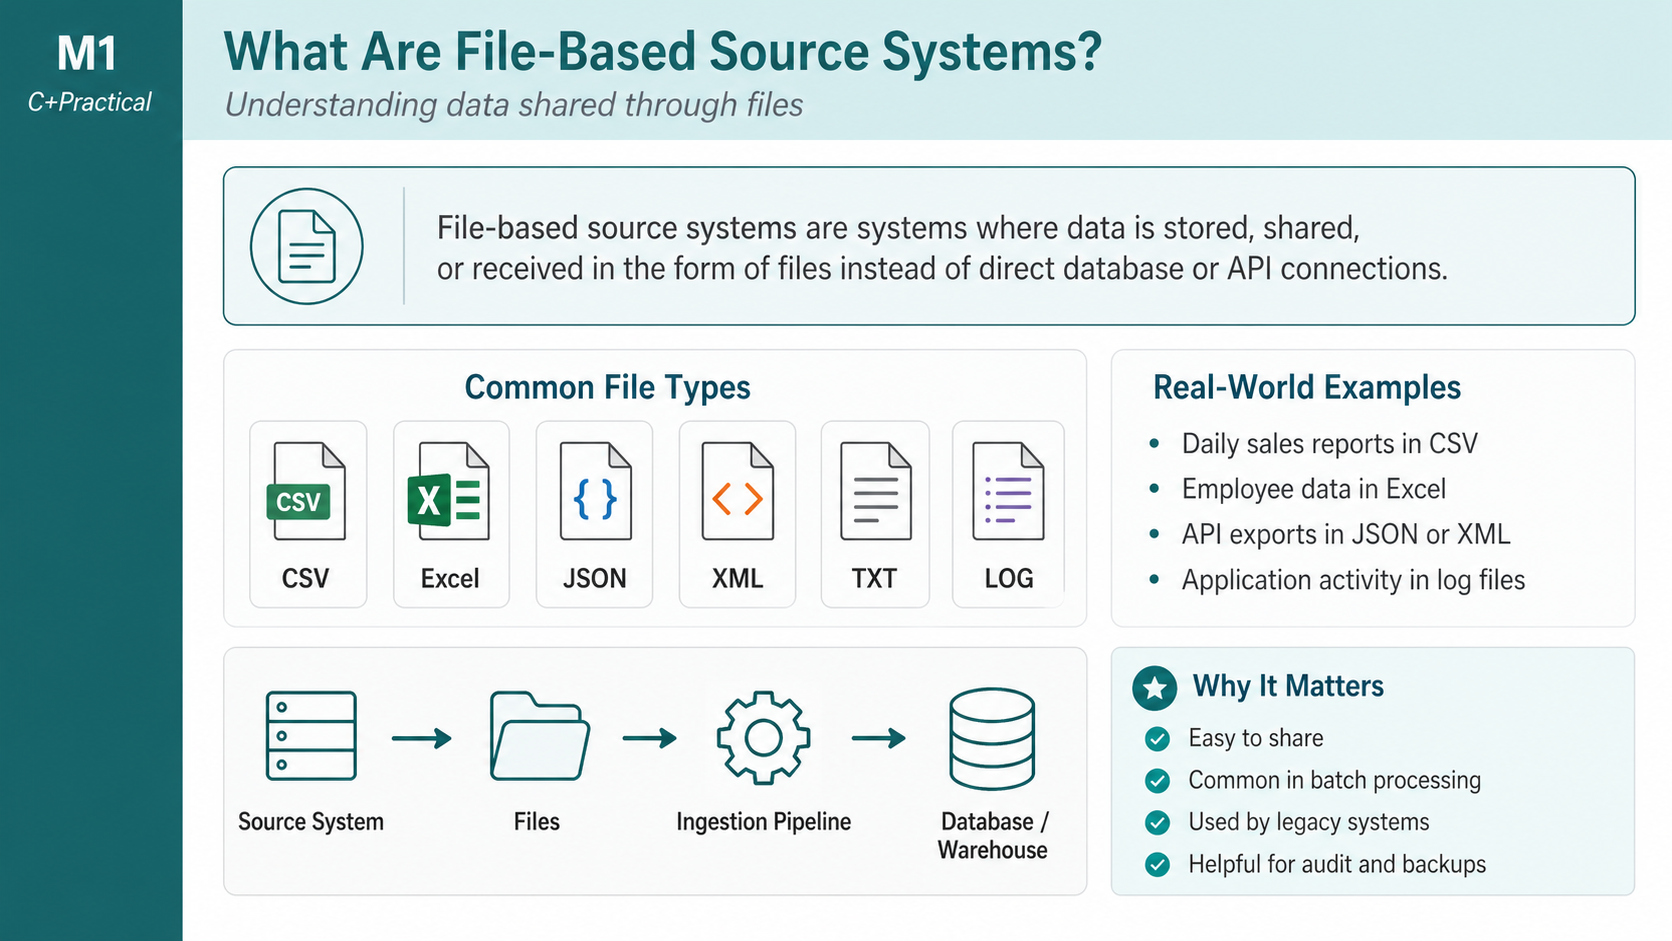

File-based ingestion means reading data from files and loading it into a system like a database, data warehouse, data lake, or processing pipeline.

In data engineering, we often receive data from:

<br> Business teams
<br> Vendors
<br> SaaS tools
<br> Banking systems

**Common File formats are**: CSV, txt, excel, json, xml, log

### CSV format

In [1]:
import pandas as pd

df = pd.read_csv("E:/data/Documents/Data_Engineering/Module1_Data_Source/module1-dataset/csv_sample.csv")

print(df.head())

   order_id customer_name  amount  order_date
0         1          Amit    1200  01-04-2026
1         2          Riya    2500  02-04-2026


**Note**: *Not every CSV uses commas. Some files use pipe |, tab, or semicolon*

```df = pd.read_csv("orders_pipe.csv", delimiter="|")```

### Excel Format

In [7]:
df = pd.read_excel("E:/data/Documents/Data_Engineering/Module1_Data_Source/module1-dataset/sample_file_based_ingestion.xlsx",
                   sheet_name="Sales_January")
df.head()

,order_id,order_date,customer_id,product,category,quantity,unit_price,discount_percent,payment_mode,order_status
0,1001,2026-01-02,101,Laptop Stand,Accessories,2,899,0.05,UPI,Delivered
1,1002,2026-01-04,102,Wireless Mouse,Accessories,1,699,0.00,Card,Delivered
2,1003,2026-01-07,103,Office Chair,Furniture,1,5499,0.10,Net Banking,Shipped
3,1004,2026-01-10,104,Keyboard,Accessories,2,1299,0.07,UPI,Delivered
4,1005,2026-01-15,105,Monitor 24 inch,Electronics,1,8999,0.12,Card,Cancelled


#### Reading multiple tabs

In [10]:
all_sheets = pd.read_excel("E:/data/Documents/Data_Engineering/Module1_Data_Source/module1-dataset/sample_file_based_ingestion.xlsx"
                           , sheet_name=None)

for sheet_name, data in all_sheets.items():
    print(sheet_name)
    print(data.head(2))

Customers
   customer_id customer_name      city        state                    email  \
0          101   Amit Sharma  Haldwani  Uttarakhand  amit.sharma@example.com   
1          102    Riya Verma     Delhi        Delhi   riya.verma@example.com   

  signup_date customer_segment  
0  2025-12-05           Retail  
1  2026-01-12           Retail  
Sales_January
   order_id order_date  customer_id         product     category  quantity  \
0      1001 2026-01-02          101    Laptop Stand  Accessories         2   
1      1002 2026-01-04          102  Wireless Mouse  Accessories         1   

   unit_price  discount_percent payment_mode order_status  
0         899              0.05          UPI    Delivered  
1         699              0.00         Card    Delivered  
Sales_February
   order_id order_date  customer_id          product     category  quantity  \
0      2001 2026-02-01          102   Wireless Mouse  Accessories         2   
1      2002 2026-02-03          104  Laptop Back

In [13]:
df = pd.read_excel("E:/data/Documents/Data_Engineering/Module1_Data_Source/module1-dataset/sample_file_based_ingestion.xlsx", 
                   sheet_name = 'Sales_Report_With_Title',
                   skiprows=3)
df.head()

,order_id,order_date,customer_id,product,category,quantity,unit_price,discount_percent,payment_mode,order_status
0,1001,2026-01-02,101,Laptop Stand,Accessories,2,899,0.05,UPI,Delivered
1,1002,2026-01-04,102,Wireless Mouse,Accessories,1,699,0.00,Card,Delivered
2,1003,2026-01-07,103,Office Chair,Furniture,1,5499,0.10,Net Banking,Shipped
3,1004,2026-01-10,104,Keyboard,Accessories,2,1299,0.07,UPI,Delivered
4,1005,2026-01-15,105,Monitor 24 inch,Electronics,1,8999,0.12,Card,Cancelled


### TXT file

In [16]:
df = pd.read_csv("E:/data/Documents/Data_Engineering/Module1_Data_Source/module1-dataset/text_sample.txt", header=None)

df.columns = ["customer_id", "name", "city"]

print(df.head())

   customer_id  name      city
0          101  Amit  Haldwani
1          102  Riya     Delhi
2          103  Neha  Rudrapur


#### Fixed-Width TXT Example

Some legacy systems generate fixed-width files. In fixed-width files, columns are identified by position, not delimiter.

In [18]:
df = pd.read_fwf("E:/data/Documents/Data_Engineering/Module1_Data_Source/module1-dataset/customers_fixed_width.txt", widths=[3, 10, 10])

df.columns = ["customer_id", "name", "city"]

print(df)

   customer_id  name      city
0          102  Riya     Delhi
1          103  Neha  Rudrapur


### JSON File format

In [19]:
df = pd.read_json("E:/data/Documents/Data_Engineering/Module1_Data_Source/module1-dataset/orders.json")

print(df.head())

   order_id customer  amount   items
0         1     Amit    1200  Laptop
1         1     Amit    1200   Mouse


#### Nested JSON

For nested json, use **with open**

In [23]:

import json

with open("E:/data/Documents/Data_Engineering/Module1_Data_Source/module1-dataset/nested_orders.json", "r") as file:
    data = json.load(file)
df = pd.json_normalize(data) #pd.json_normalize() converts nested JSON data into a flat table.

print(df)

   order_id  amount customer.name customer.city
0         1    1200          Amit      Haldwani
1         2    2500          Riya         Delhi


#### Json Lines

In production, logs and event data are often stored as JSON Lines.

In [25]:
df = pd.read_json("E:/data/Documents/Data_Engineering/Module1_Data_Source/module1-dataset/orders_jsonline.jsonl", lines=True)
df.head()

,order_id,amount
0,1,1200
1,2,2500
2,3,1800


### XML Files

XML stands for Extensible Markup Language.

It is used in many enterprise and legacy systems.

In [28]:
df = pd.read_xml("E:/data/Documents/Data_Engineering/Module1_Data_Source/module1-dataset/orders_xml.xml")

print(df.head())

   order_id customer  amount
0         1     Amit    1200
1         2     Riya    2500


### Log file

In [30]:
with open("E:/data/Documents/Data_Engineering/Module1_Data_Source/module1-dataset/orders_log.log", "r") as file:
    for line in file:
        print(line.strip())

2026-04-01 10:15:22 INFO User login successful user_id=101
2026-04-01 10:16:05 ERROR Payment failed user_id=102
2026-04-01 10:18:10 WARNING Slow API response user_id=103


In [31]:
import re # re is Python’s regular expression module.it is used to search, match, and extract patterns from text.

log_line = "2026-04-01 10:16:05 ERROR Payment failed user_id=102"

pattern = r"(\d{4}-\d{2}-\d{2}) (\d{2}:\d{2}:\d{2}) (\w+) (.*) user_id=(\d+)" # in each bracket, we have group

match = re.match(pattern, log_line) # matching the pattern

if match:
    date = match.group(1)
    time = match.group(2)
    level = match.group(3)
    message = match.group(4)
    user_id = match.group(5)

    print(date, time, level, message, user_id)

2026-04-01 10:16:05 ERROR Payment failed 102


### Reading large files in chunk

In [3]:


chunk_list = []

for chunk in pd.read_csv("E:/data/Documents/Data_Engineering/Module1_Data_Source/module1-dataset/orders_large_practice.csv", chunksize=5000):
    chunk_list.append(chunk)

combined_df = pd.concat(chunk_list, ignore_index=True)

print(combined_df.head())
print(combined_df.shape)

   order_id  customer_id  order_date   amount     status      city  \
0       1.0       1913.0  2026-04-02  11149.1  Completed     Delhi   
1       2.0       5468.0  2026-04-06  8898.34  Completed  Rudrapur   
2       3.0       2906.0  2026-05-03  9070.08  Completed      Pune   
3       4.0       4680.0  2026-05-08  4245.04  Cancelled     Delhi   
4       5.0       3788.0  2026-04-18  2416.64   Returned    Mumbai   

  payment_method  
0            UPI  
1           Card  
2           Card  
3    Net Banking  
4            UPI  
(20000, 7)
